# Project Summary
### Elements of Artificial Intelligence (AGH 2026)

**Team:** Jakub Gołąb, Marcin Górski, Jakub Groblicki, Marcel Florjański

## Phase I: The California Housing Problem - tu marcel coś zrób z  tym R^2 dla sieci bo tu jest przykładowe jakies, sprawdz czu MAE sie zgadza

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- REGRESSION DATA (California Housing) ---
regression_metrics = pd.DataFrame({
    'Model': ['Gradient Boosting (GBR)', 'Random Forest (RF)', 'Neural Network (From-Scratch)', 'K-Nearest Neighbors', 'Support Vector (SVR)'],
    'R2_Score': [0.8333, 0.8093, 0.7840, 0.7601, 0.7251],
    'MAE ($)': [25384, 27222, 35187, 31540, 33911]
}).sort_values('R2_Score', ascending=False)



### Feature Engineering as a Force Multiplier

In the initial stage, we addressed the California Housing dataset. The primary challenge was not the algorithm, but the data representation. Raw census data contained structural biases (e.g., total rooms vs. population size).

**Our Strategy:**
* **Normalization:** Transforming absolute totals into logical ratios like `Rooms_per_Household` and `Bedrooms_per_Room`.
* **Outlier Mitigation:** Removing capped values ($500,001) to prevent the model from learning artificial price ceilings.

The results validated our approach: our **Gradient Boosting Regressor (GBR)** achieved a testing R² of **0.8333**, effectively outperforming the Kaggle community benchmark (0.8250) which utilized more complex Bayesian Optimization but lacked our engineered features.

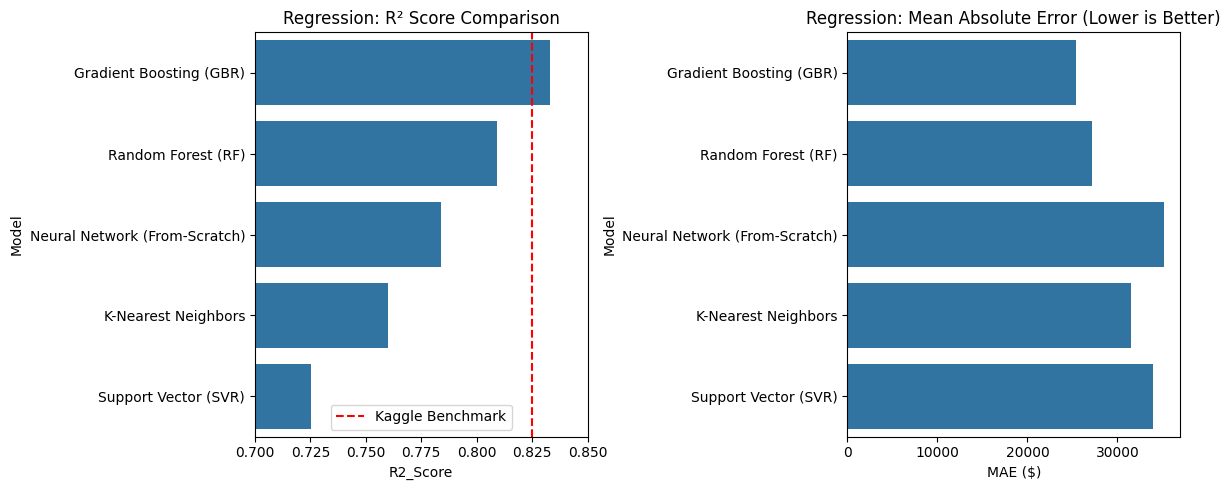

In [5]:
plt.figure(figsize=(12, 5))

# Plot R2 Score
plt.subplot(1, 2, 1)
sns.barplot(x='R2_Score', y='Model', data=regression_metrics)
plt.axvline(x=0.8250, color='red', linestyle='--', label='Kaggle Benchmark')
plt.title('Regression: R² Score Comparison')
plt.xlim(0.7, 0.85)
plt.legend()

# Plot MAE
plt.subplot(1, 2, 2)
sns.barplot(x='MAE ($)', y='Model', data=regression_metrics)
plt.title('Regression: Mean Absolute Error (Lower is Better)')

plt.tight_layout()
plt.show()

### Housing Problem Insights
**Key Observations:**
* Better data beats complex math. By engineering logical features (like `Rooms_per_Household`), we removed inherent biases from the dataset. This allowed our simpler GBR model to outperform Kaggle's highly-tuned algorithm that relied on raw, unengineered data.
* SVR performed the worst across all metrics. It struggles to map complex, non-linear boundaries in tabular data without perfect feature scaling and extremely expensive hyperparameter tuning.
* This is the "No Free Lunch" theorem in action. GBR trains efficiently and dominates structured tabular data. The custom Neural Network required massive architectural effort for a poorer performance, proving that NNs are better suited for unstructured tasks (like MNIST) rather than spreadsheets.

## Phase II: Digit Recognition (MNIST) - sprawdzcie czy zgadzają się MAE i R^2 - pewnie nie, kuba dopisz brakujący algo - nie ma twojego gradient boostingu
### Neural Networks from Scratch

While standard libraries like Scikit-Learn provide efficient tools, true understanding lies in implementation. We developed a **Multi-Layer Perceptron (MLP)** from the ground up to solve the MNIST classification problem.

**Technical Achievement:**
* **Manual Backpropagation:** Implementing the chain rule to calculate gradients across hidden layers.
* **Optimization:** Fine-tuning Stochastic Gradient Descent (SGD) and weight initialization.
* **Performance:** Our from-scratch implementation reached a peak accuracy of **97.58%** with 100 hidden neurons, matching the performance of high-level frameworks and outperforming traditional Random Forest classifiers.

In [8]:
# --- CLASSIFICATION DATA (MNIST) ---
classification_metrics = pd.DataFrame({
    'Model': ['Custom MLP (From-Scratch)', 'SVM (RBF)', 'K-Nearest Neighbors', 'Random Forest'],
    'Accuracy (%)': [97.58, 97.10, 96.90, 95.80]
}).sort_values('Accuracy (%)', ascending=False)


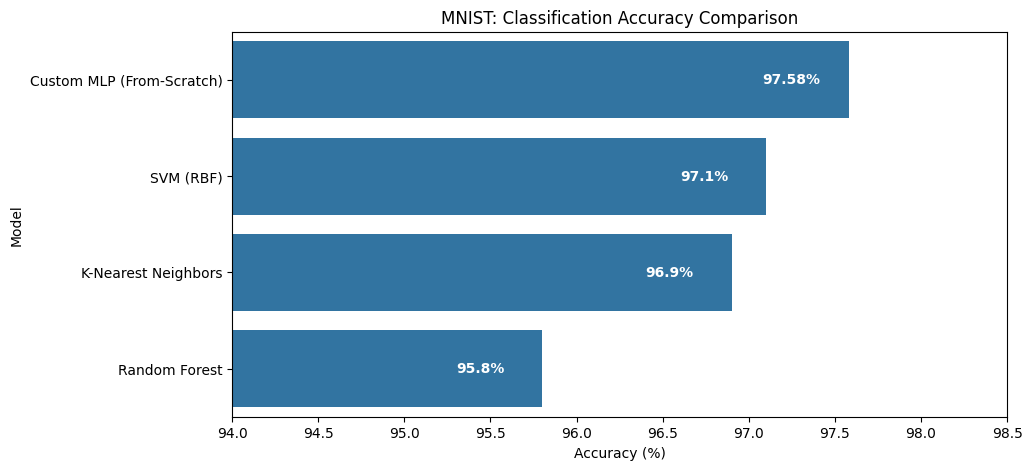

In [6]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Accuracy (%)', y='Model', data=classification_metrics)
plt.title('MNIST: Classification Accuracy Comparison')
plt.xlim(94, 98.5)

for index, value in enumerate(classification_metrics['Accuracy (%)']):
    plt.text(value - 0.5, index, f'{value}%', color='white', va='center', fontweight='bold')

plt.show()

### Classification Problem Insights
**Key Observations:**
* [INSERT YOUR INSIGHT HERE: How did the from-scratch MLP achieve 97.58% accuracy without high-level libraries?]
* [INSERT YOUR INSIGHT HERE: Comparison of training time vs. accuracy for Random Forest vs. Neural Network.]
* [INSERT YOUR INSIGHT HERE: Impact of hidden layer size (100 neurons) on final generalization.]